# 05. Disagreement Cases and Mechanism Hypotheses

Five specific points illustrate three distinct disagreement patterns between
satellite RTS and BLM debris density, then three candidate mechanisms are
tested and — honestly — not supported by the data:

1. Activity/equipment intensity (DPW vs. HEaT counterexample)
2. Baseline texture heterogeneity (pixel std + GLCM contrast vs. RTS)
3. Absolute debris quantity / proximity to the detection threshold

None of these explain why some high-debris points show low RTS (or vice
versa). The specific mechanism remains an open question — see the paper's
Discussion/Limitations.


## Setup

This notebook is self-contained: it re-runs Drive mounting, imports, GEE
auth, and (if needed) DINOv2 loading, so it can be run on its own without
depending on any other notebook having been run first in the same session.
Cached patches/rasters from other notebooks are still reused automatically
via the shared `CACHE_DIR`.


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
CACHE_DIR = "/content/drive/MyDrive/burning_man_cache/patch_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


Mounted at /content/drive


In [3]:
import sys
sys.path.append("/content/drive/MyDrive/burning_man_repo")

from src.gee_utils import get_patch, get_patch_cached, fetch_bulk_raster_cached
from src.features import patch_to_pil, extract_feature, extract_patch_tokens, cosine_distance, compute_patch_heatmap
from src.stats import compare_groups


In [4]:
import ee
from config import GEE_PROJECT_ID

ee.Authenticate()
ee.Initialize(project=GEE_PROJECT_ID)


In [5]:
BASELINE_START, BASELINE_END = "2023-08-01", "2023-08-20"
EVENT_START, EVENT_END = "2023-10-05", "2023-10-18"
LATE_START, LATE_END = "2023-11-01", "2023-11-20"

WINDOWS = {
    "baseline": (BASELINE_START, BASELINE_END),
    "pei_period": (EVENT_START, EVENT_END),
    "late": (LATE_START, LATE_END),
}


In [6]:
!pip install transformers torch --quiet

import torch
from transformers import AutoImageProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_name = "facebook/dinov2-base"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()


Using device: cpu


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

In [7]:
!pip install scikit-image --quiet


## Load data

In [8]:
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/burning_man_repo/data"
df = pd.read_csv(f"{DATA_DIR}/blm_pei_2023_latlon_final.csv")


## Compute point-level RTS (buffer_m=35) for all 33 points

Only the primary scale is needed here (the scale sweep itself lives in
`04_ground_truth_comparison.ipynb`).


In [9]:
BUFFER_M = 35

point_results = []
for _, row in df.iterrows():
    baseline_patch = get_patch_cached(CACHE_DIR, row["site_id"], "baseline", row["lat"], row["lon"],
                                       *WINDOWS["baseline"], buffer_m=BUFFER_M)
    pei_patch = get_patch_cached(CACHE_DIR, row["site_id"], "pei_period", row["lat"], row["lon"],
                                  *WINDOWS["pei_period"], buffer_m=BUFFER_M)
    baseline_feat = extract_feature(baseline_patch, model, processor, device)
    pei_feat = extract_feature(pei_patch, model, processor, device)
    point_results.append({
        "site_id": row["site_id"], "rts": cosine_distance(baseline_feat, pei_feat),
        "debris_ft2_per_acre": row["debris_ft2_per_acre"], "category": row["category"],
    })

points_df = pd.DataFrame(point_results).set_index("site_id")
points_df.head()


,rts,debris_ft2_per_acre,category
site_id,,,
The_Man,0.268851,0.10,POI
The_Temple,0.311787,0.76,POI
USS,0.581376,0.90,POI
DPW,0.363591,0.02,POI
JOC,0.260321,0.29,POI


## The five disagreement cases

| Site | BLM debris | Pattern |
|---|---|---|
| DPW | 0.02 (near-perfectly clean) | Highest satellite RTS of the five — satellite says "changed a lot," ground says "clean" |
| HEaT | 1.02 (the one POI that fails) | Near-noise-level RTS — direct counterexample to the "equipment intensity" hypothesis |
| CG_60 | 4.54 (highest in the dataset) | Largest visible RGB color shift, but only mid-range RTS |
| OP_35 / OP_39 | 1.81 / 1.66 (both fail) | RTS ~= 0 — satellite essentially can't tell these apart from baseline |


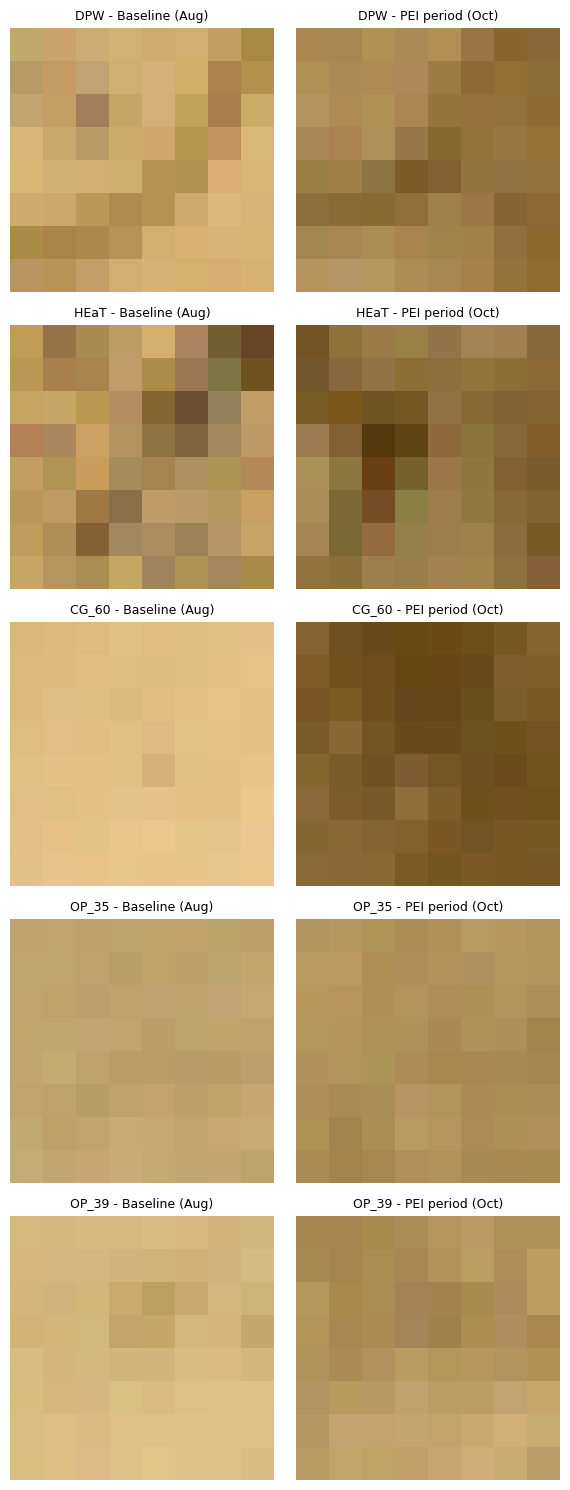

              rts  debris_ft2_per_acre           category
site_id                                                  
DPW      0.363591                 0.02                POI
HEaT     0.216184                 1.02                POI
CG_60    0.296884                 4.54  replaced_excluded
OP_35    0.178928                 1.81  replaced_excluded
OP_39    0.188317                 1.66  replaced_excluded


In [10]:
import numpy as np
import matplotlib.pyplot as plt

STRETCH_MIN = 2000
STRETCH_MAX = 5500

sites_of_interest = ["DPW", "HEaT", "CG_60", "OP_35", "OP_39"]

fig, axes = plt.subplots(len(sites_of_interest), 2, figsize=(6, 3 * len(sites_of_interest)))

for i, site_id in enumerate(sites_of_interest):
    row = df[df["site_id"] == site_id].iloc[0]
    baseline_patch = get_patch_cached(CACHE_DIR, site_id, "baseline", row["lat"], row["lon"],
                                       *WINDOWS["baseline"], buffer_m=BUFFER_M)
    pei_patch = get_patch_cached(CACHE_DIR, site_id, "pei_period", row["lat"], row["lon"],
                                  *WINDOWS["pei_period"], buffer_m=BUFFER_M)

    for ax, patch, label in zip(axes[i], [baseline_patch, pei_patch], ["Baseline (Aug)", "PEI period (Oct)"]):
        rgb = patch[:, :, [2, 1, 0]]
        rgb_stretched = np.clip((rgb - STRETCH_MIN) / (STRETCH_MAX - STRETCH_MIN), 0, 1)
        ax.imshow(rgb_stretched)
        ax.set_title(f"{site_id} - {label}", fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.savefig("disagreement_cases.png", dpi=150)
plt.show()

print(points_df.loc[sites_of_interest])


## Hypothesis 1: activity / equipment intensity

DPW (highest RTS) and HEaT (near-zero RTS) are both official POIs
specifically justified by heavy equipment / high-use activity in the BLM
report. If activity intensity drove RTS, both should show elevated values —
they don't. **Not supported.**


In [11]:
print(points_df.loc[["DPW", "HEaT"], ["rts", "debris_ft2_per_acre"]])


              rts  debris_ft2_per_acre
site_id                               
DPW      0.363591                 0.02
HEaT     0.216184                 1.02


## Hypothesis 2: baseline texture heterogeneity

Tests whether a visually "busier" baseline patch leaves less room for RTS to
register (i.e. expects a *negative* correlation between baseline texture
heterogeneity and RTS).


In [12]:
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import spearmanr

def texture_std(patch):
    rgb = patch[:, :, [2, 1, 0]]
    rgb_stretched = np.clip((rgb - STRETCH_MIN) / (STRETCH_MAX - STRETCH_MIN), 0, 1)
    return float(np.mean([rgb_stretched[:, :, c].std() for c in range(3)]))

def texture_glcm_contrast(patch):
    rgb = patch[:, :, [2, 1, 0]]
    rgb_stretched = np.clip((rgb - STRETCH_MIN) / (STRETCH_MAX - STRETCH_MIN), 0, 1)
    gray = (rgb_stretched.mean(axis=-1) * 255).astype(np.uint8)
    glcm = graycomatrix(gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    return float(graycoprops(glcm, "contrast")[0, 0])

texture_rows = []
for _, row in df.iterrows():
    baseline_patch = get_patch_cached(CACHE_DIR, row["site_id"], "baseline", row["lat"], row["lon"],
                                       *WINDOWS["baseline"], buffer_m=BUFFER_M)
    if baseline_patch is None:
        continue
    texture_rows.append({"site_id": row["site_id"], "baseline_std": texture_std(baseline_patch),
                          "baseline_glcm_contrast": texture_glcm_contrast(baseline_patch)})

texture_df = pd.DataFrame(texture_rows).set_index("site_id")
merged_tex = points_df.join(texture_df).dropna(subset=["rts", "baseline_std", "baseline_glcm_contrast"])

rho_std, p_std = spearmanr(merged_tex["baseline_std"], merged_tex["rts"])
rho_glcm, p_glcm = spearmanr(merged_tex["baseline_glcm_contrast"], merged_tex["rts"])

print(f"baseline_std vs rts:           rho={rho_std:.3f}, p={p_std:.3f}, n={len(merged_tex)}")
print(f"baseline_glcm_contrast vs rts: rho={rho_glcm:.3f}, p={p_glcm:.3f}, n={len(merged_tex)}")
print()
print(merged_tex.loc[merged_tex.index.isin(["DPW", "HEaT"]),
                     ["baseline_std", "baseline_glcm_contrast", "rts"]])


baseline_std vs rts:           rho=-0.061, p=0.737, n=33
baseline_glcm_contrast vs rts: rho=0.067, p=0.713, n=33

         baseline_std  baseline_glcm_contrast       rts
site_id                                                
DPW          0.062704              241.303571  0.363591
HEaT         0.084505              471.142857  0.216184


**Not supported** — both correlations are near zero and non-significant,
and HEaT's baseline heterogeneity is numerically *higher* than DPW's (the
opposite of what the hypothesis predicts).

## Hypothesis 3: absolute debris quantity / proximity to detection threshold

Among points that fail the BLM standard (debris > 1.0 ft2/acre), does RTS
track how far above threshold the debris value is? Splits the failing
points into a high-RTS and low-RTS subgroup (top 20% of RTS among all 33
points, consistent with the threshold used in `06`) and compares their
debris values.


In [13]:
HIGH_RTS_THRESHOLD = points_df["rts"].quantile(0.80)

failing = points_df[points_df["debris_ft2_per_acre"] > 1.0].copy()
failing["high_rts"] = failing["rts"] > HIGH_RTS_THRESHOLD

low_rts_group = failing.loc[~failing["high_rts"], "debris_ft2_per_acre"]
high_rts_group = failing.loc[failing["high_rts"], "debris_ft2_per_acre"]

result = compare_groups(low_rts_group, high_rts_group, label_a="low_rts_high_debris", label_b="high_rts_high_debris")
for k, v in result.items():
    print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")


low_rts_high_debris_mean: 1.718
low_rts_high_debris_median: 1.430
low_rts_high_debris_n: 16
high_rts_high_debris_mean: 1.478
high_rts_high_debris_median: 1.060
high_rts_high_debris_n: 5
statistic: 51.000
p_value: 0.385


**Not supported** — the two groups' debris values are not significantly
different; low-RTS failing points are not simply "barely over threshold"
compared to high-RTS failing points.

## Summary table


In [14]:
summary = pd.DataFrame([
    {"hypothesis": "Activity / equipment intensity",
     "test": "DPW vs. HEaT counterexample",
     "result": "Not supported"},
    {"hypothesis": "Baseline texture heterogeneity",
     "test": "Spearman(baseline_std or GLCM contrast, RTS)",
     "result": "No significant evidence"},
    {"hypothesis": "Absolute debris quantity / threshold proximity",
     "test": "Mann-Whitney U (low-RTS vs. high-RTS failing points)",
     "result": "No significant evidence"},
])
summary.to_csv("mechanism_hypotheses_summary.csv", index=False)
summary


,hypothesis,test,result
0,Activity / equipment intensity,DPW vs. HEaT counterexample,Not supported
1,Baseline texture heterogeneity,"Spearman(baseline_std or GLCM contrast, RTS)",No significant evidence
2,Absolute debris quantity / threshold proximity,Mann-Whitney U (low-RTS vs. high-RTS failing p...,No significant evidence
